In [5]:
import sys
sys.path.append("..")
sys.path.append("../scripts")
from scripts.paths import raw_customer_churn_path, clean_customer_churn_path
from scripts.preprocessing import load_data, inspect_data, clean_data

In [7]:
df = load_data(clean_customer_churn_path)

========== Data Load Sucessfully ==========


In [11]:
inspect_data(df)

===== First Five Rows =====
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Streamin

In [15]:
X = df[['tenure', 'MonthlyCharges']]

In [27]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

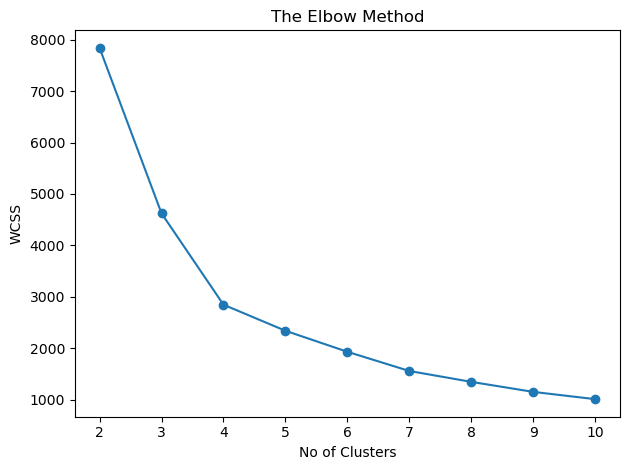

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scripts.paths import clustering_visuals_path
wcss =[]
for i in range(2,11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init = 10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(2,11), wcss, marker ='o')
plt.title("The Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
elbow_path = os.path.join(clustering_visuals_path, "elbow_method.png")
plt.savefig(elbow_path, dpi = 300, bbox_inches ='tight')
plt.tight_layout()
plt.show()
plt.close()

Clusters: 2 Score: 0.4108429987584872
Clusters: 3 Score: 0.4464529274900921
Clusters: 4 Score: 0.47618099502253247
Clusters: 5 Score: 0.4301552810906812
Clusters: 6 Score: 0.4154476138976147
Clusters: 7 Score: 0.43394655842142077
Clusters: 8 Score: 0.4328440949451135
Clusters: 9 Score: 0.439953923257533
Clusters: 10 Score: 0.4304598598845638


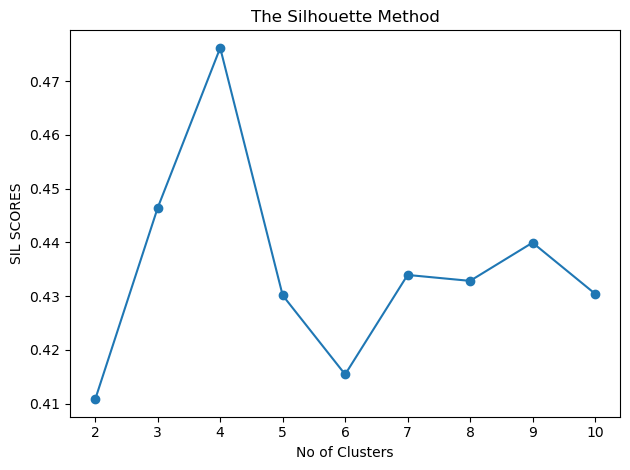

In [57]:
sil_score =[]
for i in range (2,11):
    kmeans = KMeans(n_clusters = i, init ='k-means++', random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_score.append(score)
    print("Clusters:", i, "Score:", score )
plt.plot(range(2,11), sil_score, marker ='o')
plt.title("The Silhouette Method")
plt.xlabel("No of Clusters")
plt.ylabel("SIL SCORES")
sil_path = os.path.join(clustering_visuals_path, "silhouette_method.png")
plt.savefig(sil_path, dpi = 300, bbox_inches ='tight')
plt.tight_layout()
plt.show()
plt.close()

In [61]:
# using k = 4 as number of clusters
kmeans = KMeans(n_clusters = 4, init ='k-means++', random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [63]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


In [65]:
cluster_summary = df.groupby('Cluster').agg(
    Customers=('customerID', 'count'),
    Avg_Tenure=('tenure', 'mean'),
    Avg_MonthlyCharges=('MonthlyCharges', 'mean')
)

cluster_summary

,Customers,Avg_Tenure,Avg_MonthlyCharges
Cluster,,,
0,1732,10.487875,32.470699
1,1952,58.748975,93.019621
2,2204,14.811252,81.215903
3,1155,54.115152,34.028745


In [69]:
import pandas as pd
cluster_churn = pd.crosstab(
    df['Cluster'],
    df['Churn'],
    normalize='index'
) * 100

cluster_churn

Churn,No,Yes
Cluster,,
0,75.461894,24.538106
1,84.375000,15.625000
2,50.816697,49.183303
3,95.238095,4.761905


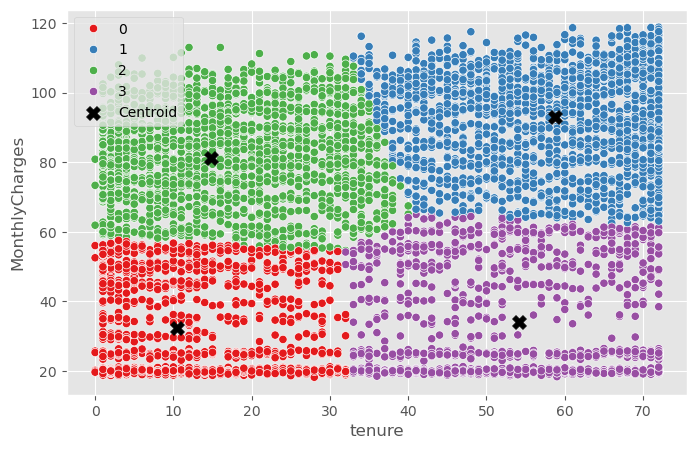

In [95]:
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
sns.scatterplot(data = df, x = 'tenure', y= 'MonthlyCharges', hue = 'Cluster', palette ='Set1')
centroid_scaled = kmeans.cluster_centers_
centroid = sc.inverse_transform(centroid_scaled)
plt.scatter(centroid[:,0], centroid[:,1], marker ='X', color = 'black', s = 100, label = 'Centroid')
plt.legend()
cluster_plot= os.path.join(clustering_visuals_path, 'customer_segments.png')
plt.savefig(cluster_plot, dpi = 300, bbox_inches ='tight')
plt.show()
plt.close()